# Arabidopsis root cortex cell detection and tracking — minimal Colab reproduction

**Paper:** Goh, Song, Yonekura, et al., *In-Depth Quantification of Cell Division and Elongation Dynamics at the Tip of Growing Arabidopsis Roots Using 4D Microscopy, AI-Assisted Image Processing and Data Sonification*, Plant and Cell Physiology 64(11):1262–1278 (2023). DOI [10.1093/pcp/pcad105](https://doi.org/10.1093/pcp/pcad105) (PMC10700013).

**Author code:** [JerrySongCST/Arabidopsis_root_cortex_cell_tracking](https://github.com/JerrySongCST/Arabidopsis_root_cortex_cell_tracking) @ commit `9be8f8110a069186b4eb8510b95b2fb2490e390a` (no LICENSE file in the repository; usage terms follow the authors' stated citation request).

**Scope of this notebook (partial demonstration):** run the authors' pre-trained **2D U-Net** slice-by-slice nuclei detection on the **10 sample frames** the authors provide for testing, then run their **GA + k-means cell-file clustering** and **lineage tracking**, export a **TrackMate-compatible XML**, and compare the detections against the **ground-truth XML** included with the samples. This is a single-example plausibility check — it does **not** reproduce the paper's dataset-level accuracies (precision/recall over full 4D images) or the division-dynamics analyses.

**Execution status:** executed in Colab (see saved outputs). Recommended runtime: **T4 GPU** (the authors strongly recommend GPU for detection); a CPU runtime also works with slower detection (~10–15 min). The notebook auto-detects the device.

**AI-assisted headless port:** the authors provide this pipeline as a **PySide2 GUI** (`launch.py`). This notebook reuses the authors' computational modules (`cell_detection.py`, `ga.py`) **unmodified** and re-expresses the GUI button sequence ("Automatic Detect" → "Automatic Clustering" → "Reset Cell ID" → "Track Cells" → "Save XML") as headless cells. The GUI itself, manual-correction tools, and TrackMate/MaMuT interaction are omitted. **AI-assisted translation from the author GUI; the authors did not provide this headless Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed.**

**日本語:** このノートブックは、著者らが公開している学習済み 2D U-Net による核検出と、GA + k-means による細胞列クラスタリング・系譜追跡を、提供された 10 サンプルフレームで実行し、付属の正解 XML と比較する最小再現デモです。推奨ランタイムは **T4 GPU**（CPU も可、検出は低速）。著者の PySide2 GUI をヘッドレス化した **AI 支援の移植**であり、計算本体は著者コードをそのまま使用しています。

**References:** Song et al. 2025 (arXiv:2504.12676) — tracking method; Song et al. 2024 (IEICE Proc. S5-3) — U-Net detection.


## 0. Runtime selection

**Select Runtime → Change runtime type → T4 GPU** (recommended) or CPU. Run all cells top to bottom.
Expected: ~5 min on T4, ~15–25 min on CPU (dominated by U-Net inference on ~290 slices and the GA search). Downloads: author code (~110 KB), 2 checkpoints, and the sample frame folder (sizes shown at runtime).

**ランタイムの選択:** 「ランタイム → ランタイムのタイプを変更」で **T4 GPU**（推奨）または CPU を選び、上から順に実行してください。

The next cell prints the detected hardware so you can confirm the allocated runtime before any heavy work.


In [ ]:
import torch, sys, platform
print("Python", platform.python_version())
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Python 3.13.15
torch 2.11.0+cu130 | CUDA available: True
GPU: Tesla T4
Using device: cuda


## 1. Dependencies

The computation needs `tifffile` (ImageJ TIFF metadata), `openpyxl` (per-frame annotation workbooks the author code writes), and `gdown` (Google Drive downloads). `torch`, `scikit-image`, `scikit-learn`, `pandas`, `scipy`, `matplotlib` are preinstalled on Colab.

**日本語:** 著者コードが必要とする `tifffile`・`openpyxl` と、Google Drive ダウンロード用の `gdown` をインストールします（Colab には他の依存は既に入っています）。


In [ ]:
%pip install -q gdown tifffile openpyxl
import importlib
for m in ("gdown", "tifffile", "openpyxl", "skimage", "sklearn", "scipy", "pandas"):
    mod = importlib.import_module(m)
    print(m, getattr(mod, "__version__", "ok"))


gdown 5.2.2


tifffile 2026.9.15


openpyxl 3.1.5
skimage 0.25.2


sklearn 1.6.1
scipy 1.16.3
pandas 2.2.3


## 2. Author source code (pinned revision)

Fetch the two computational modules **unmodified** from the pinned commit `9be8f8110a069186b4eb8510b95b2fb2490e390a` via GitHub raw URLs (code only, no data) and verify their Git blob SHA-1 hashes:

- `cell_detection.py` — U-Net definitions (`UNet` 2D, `unet3d`), slice prediction `test_model` / `test_3d`, centroid extraction.
- `ga.py` — GA plane optimization `ga_plane`, k-means `k_means_8_line`, TrackMate XML I/O, tracking/linking (`link_spots`, `tracked_cells_to_xml`).

**日本語:** 著者リポジトリの計算モジュール 2 つをピン留めしたコミットから取得し、Git blob SHA-1 で改変がないことを確認します（データは一切含めません）。


In [ ]:
import hashlib, urllib.request, os
os.makedirs("/content/author_code", exist_ok=True)
EXPECTED = {  # git blob sha1 at commit 9be8f8110a069186b4eb8510b95b2fb2490e390a
    "cell_detection.py": "cf18b40f4694046bfdc98f2a14cc48deef8cc21b",
    "ga.py": "17ffbfd16ac54c03bface428f934edf818ad32b3",
}
def blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
for fname, sha in EXPECTED.items():
    url = f"https://raw.githubusercontent.com/JerrySongCST/Arabidopsis_root_cortex_cell_tracking/9be8f8110a069186b4eb8510b95b2fb2490e390a/{fname}"
    data = urllib.request.urlopen(url, timeout=60).read()
    assert blob_sha1(data) == sha, f"blob hash mismatch for {fname}"
    with open(f"/content/author_code/{fname}", "wb") as f:
        f.write(data)
    print(fname, len(data), "bytes, blob sha1 OK")
import sys
sys.path.insert(0, "/content/author_code")


cell_detection.py 23356 bytes, blob sha1 OK
ga.py 77324 bytes, blob sha1 OK


## 3. Pre-trained model checkpoints

The README instructs users to download the detection checkpoints from the authors' public Google Drive folder `1XdNGD-tufMjMFptxqqRKve0RJdr8RXB9` and place them next to the code as `unet_2d_best_goh.pth` (2D) and `3d_unet_best_goh.pth` (3D). We download **inside Colab only** and verify they are real Torch serialization files (not HTML error pages), then print their sizes.

**日本語:** README の指示どおり、著者の公開 Google Drive フォルダからチェックポイントを Colab 内でダウンロードし、Torch 形式であることを確認してサイズを表示します。


In [ ]:
import gdown
WEIGHTS_DIR = "/content/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
gdown.download_folder(id="1XdNGD-tufMjMFptxqqRKve0RJdr8RXB9", output=WEIGHTS_DIR, quiet=False, use_cookies=False)
for root, _, files in os.walk(WEIGHTS_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        size = os.path.getsize(p)
        with open(p, "rb") as fh:
            magic = fh.read(4)
        print(p, size, "bytes, magic:", magic[:2])


Retrieving folder contents


Processing file 11FgWLMITLALXhYI9voSmHQg2W4EUArGv 3d_unet_best_goh.pth
Processing file 18erXHWR1SSJeCV9ovFyTQeZ-KPth9iO9 unet_2d_best_goh.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed


Downloading...
From (original): https://drive.google.com/uc?id=11FgWLMITLALXhYI9voSmHQg2W4EUArGv
From (redirected): https://drive.google.com/uc?id=11FgWLMITLALXhYI9voSmHQg2W4EUArGv&confirm=t&uuid=568bf822-4129-41c9-ae7c-e0d88cd11057
To: /content/weights/3d_unet_best_goh.pth


  0%|          | 0.00/252M [00:00<?, ?B/s]

...

 99%|█████████▉| 468M/473M [00:20<00:00, 24.7MB/s]

100%|█████████▉| 471M/473M [00:20<00:00, 24.5MB/s]

100%|██████████| 473M/473M [00:20<00:00, 22.8MB/s]

/content/weights/3d_unet_best_goh.pth 251679057 bytes, magic: b'PK'
/content/weights/unet_2d_best_goh.pth 472837945 bytes, magic: b'PK'



Download completed


### Place the 2D checkpoint where the author code expects it

The author GUI loads `./unet_2d_best_goh.pth`; we copy the downloaded 2D checkpoint to that name under `/content/author_code` and record its SHA-256. If the folder contains additional files (e.g. the 3D checkpoint), we list them but use only the 2D model, which is the paper's primary slice-by-slice detector.

**日本語:** 著者コードが期待するパスに 2D 用チェックポイントをコピーし、SHA-256 を記録します。


In [ ]:
import glob, hashlib
pths = sorted(glob.glob("/content/weights/**/*.pth", recursive=True))
assert pths, "No .pth checkpoint found in the weights folder"
ckpt_2d = next((p for p in pths if "2d" in os.path.basename(p).lower()), pths[0])
dst = "/content/author_code/unet_2d_best_goh.pth"
if os.path.abspath(ckpt_2d) != os.path.abspath(dst):
    import shutil; shutil.copyfile(ckpt_2d, dst)
h = hashlib.sha256(open(dst, "rb").read()).hexdigest()
print("2D checkpoint:", dst, os.path.getsize(dst), "bytes\nsha256:", h)
print("All checkpoints:", [os.path.basename(p) for p in pths])


2D checkpoint: /content/author_code/unet_2d_best_goh.pth 472837945 bytes
sha256: ad5b9222caff194db87c7db413f67a460ce9669a48630153a47224693aec7a84
All checkpoints: ['3d_unet_best_goh.pth', 'unet_2d_best_goh.pth']


## 4. Sample frames and ground truth (test data)

Download the authors' **10 sample frames** ("we provide 10 sample frames for testing... Ground-truth cell locations and types are included for tracking validation", README §Dataset) from public Drive folder `1l8Ij9N3ODNBB29kc-vXhjcDnrSU2eUdR`, inside Colab only. We then **inspect the actual structure** — the exact file layout (one 4D TIFF vs. one 3D TIFF per time point) and the ground-truth XML schema are only resolvable from the downloaded bytes.

**日本語:** 著者提供の 10 サンプルフレームと正解 XML を Colab 内でダウンロードし、実際のフォルダ構成を確認します。


In [ ]:
DATA_DIR = "/content/sample_data"
os.makedirs(DATA_DIR, exist_ok=True)
gdown.download_folder(id="1l8Ij9N3ODNBB29kc-vXhjcDnrSU2eUdR", output=DATA_DIR, quiet=False, use_cookies=False)
for root, _, files in os.walk(DATA_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(p, os.path.getsize(p), "bytes")


Retrieving folder contents


Processing file 1ICQ5uqyFr-PBdbwOlhElocEv8qeDSEny C2-PointCO2_1_hyper(t101-110)_v45-5.xml
Processing file 1omK4EjuSOh6QAuBdresi1u2UIWxi9K5p C2-PointCO2_1_hyper(t101-110).tif


Retrieving folder contents completed
Building directory structure
Building directory structure completed


Downloading...
From (original): https://drive.google.com/uc?id=1ICQ5uqyFr-PBdbwOlhElocEv8qeDSEny
From (redirected): https://drive.google.com/uc?id=1ICQ5uqyFr-PBdbwOlhElocEv8qeDSEny&confirm=t&uuid=35b66f92-4111-4cbb-9a0a-018fbe576232
To: /content/sample_data/C2-PointCO2_1_hyper(t101-110)_v45-5.xml


  0%|          | 0.00/3.17M [00:00<?, ?B/s]

...

 92%|█████████▏| 292M/319M [00:03<00:00, 103MB/s]

 96%|█████████▋| 307M/319M [00:03<00:00, 115MB/s]

100%|██████████| 319M/319M [00:03<00:00, 97.1MB/s]

/content/sample_data/C2-PointCO2_1_hyper(t101-110).tif 318568161 bytes
/content/sample_data/C2-PointCO2_1_hyper(t101-110)_v45-5.xml 3174430 bytes
/content/sample_data/README.md 962 bytes
/content/sample_data/anscombe.json 1697 bytes
/content/sample_data/california_housing_test.csv 301141 bytes
/content/sample_data/california_housing_train.csv 1706430 bytes
/content/sample_data/mnist_test.csv 18289443 bytes
/content/sample_data/mnist_train_small.csv 36523880 bytes



Download completed


### Inspect the downloaded sample structure

Read every TIFF with `tifffile` to print its axes/shape and ImageJ metadata (pixel size, voxel depth, frame interval), and parse every XML to count `SpotsInFrame` entries. This determines how the detection/tracking working directory is laid out and resolves the calibration values (`pixelwidth`, `pixelheight`, `voxeldepth`, `timeinterval`) that the author code reads from the TIFF's ImageJ tags via `create_blank_xml`.

**日本語:** 各 TIFF の軸・形状・ImageJ メタデータ（画素サイズ、ボクセル深さ、フレーム間隔）と各 XML のスポット数を確認します。これらの値は著者コード `create_blank_xml` が TIFF タグから読み取る較正値です。


In [ ]:
import tifffile, glob
import xml.etree.ElementTree as ET
tifs = sorted(glob.glob("/content/sample_data/**/*.tif*", recursive=True))
xmls = sorted(glob.glob("/content/sample_data/**/*.xml", recursive=True))
print("TIFFs:", [os.path.basename(t) for t in tifs])
for t in tifs:
    with tifffile.TiffFile(t) as tf:
        s = tf.series[0]
        print(os.path.basename(t), s.shape, s.axes)
        try:
            md_ = tf.imagej_metadata
            print("  imagej metadata:", md_)
        except Exception as e:
            print("  no imagej metadata:", e)
for x in xmls:
    root = ET.parse(x).getroot()
    frames = root.findall(".//SpotsInFrame")
    spots = sum(len(f.findall("Spot")) for f in frames)
    imgdata = root.findall(".//ImageData")
    cal = {k: imgdata[0].get(k) for k in ("pixelwidth","pixelheight","voxeldepth","timeinterval","nframes","nslices")} if imgdata else {}
    print(os.path.basename(x), "| frames:", len(frames), "| total spots:", spots, "|", cal)


TIFFs: ['C2-PointCO2_1_hyper(t101-110).tif']
C2-PointCO2_1_hyper(t101-110).tif (10, 29, 1054, 521) TZYX
  imagej metadata: {'ImageJ': '1.53f', 'images': 290, 'slices': 29, 'frames': 10, 'hyperstack': True, 'unit': 'micron', 'finterval': 900, 'spacing': 2.5, 'loop': False, 'min': 24.0, 'max': 250.0, 'Labels': ['t:5802/18154 - PointCO2_1.tif', 't:5804/18154 - PointCO2_1.tif', 't:5806/18154 - PointCO2_1.tif', 't:5808/18154 - PointCO2_1.tif', 't:5810/18154 - PointCO2_1.tif', 't:5812/18154 - PointCO2_1.tif', 't:5814/18154 - PointCO2_1.tif', 't:5816/18154 - PointCO2_1.tif', 't:5818/18154 - PointCO2_1.tif', 't:5820/18154 - PointCO2_1.tif', 't:5822/18154 - PointCO2_1.tif', 't:5824/18154 - PointCO2_1.tif', 't:5826/18154 - PointCO2_1.tif', 't:5828/18154 - PointCO2_1.tif', 't:5830/18154 - PointCO2_1.tif', 't:5832/18154 - PointCO2_1.tif', 't:5834/18154 - PointCO2_1.tif', 't:5836/18154 - PointCO2_1.tif', 't:5838/18154 - PointCO2_1.tif', 't:5840/18154 - PointCO2_1.tif', 't:5842/18154 - PointCO2_1.ti

C2-PointCO2_1_hyper(t101-110)_v45-5.xml | frames: 10 | total spots: 3729 | {'pixelwidth': '0.6100000976000156', 'pixelheight': '0.6100000976000156', 'voxeldepth': '2.5', 'timeinterval': '900.0', 'nframes': '10', 'nslices': '29'}


### Build the working directory for the author pipeline

The author GUI operates on a folder holding one 4D TIFF (T×Z×Y×X) plus a detection XML. If the download already contains a single 4D TIFF we use it directly; if instead it contains one 3D stack per time point, we **stack them into one ImageJ-hyperstack TIFF** (documented adaptation, calibration copied from the ground-truth XML's `ImageData` and cross-checked against the TIFF tags). The ground-truth XML is kept outside the detection working folder, as the README requires (a same-named XML must not sit next to the TIFF).

**日本語:** 著者パイプライン用の作業フォルダを作成します。4D TIFF が 1 つあればそのまま使い、時間点ごとの 3D TIFF 群なら 1 枚の ImageJ ハイパースタックに統合します（較正値は正解 XML の ImageData からコピーし、明示した適応です）。


In [ ]:
import numpy as np, shutil, re
WORK = "/content/work"
os.makedirs(WORK, exist_ok=True)
imgdata = None
gt_xml = None
for x in xmls:  # identify the ground-truth file by its ImageData/calibration
    root = ET.parse(x).getroot()
    if root.findall(".//ImageData"):
        gt_xml = x
        imgdata = root.findall(".//ImageData")[0]
        break
def cal(attr):
    return float(imgdata.get(attr)) if imgdata is not None and imgdata.get(attr) else None

fourd = [t for t in tifs if len(tifffile.TiffFile(t).series[0].shape) >= 4]
if fourd:
    src = fourd[0]
    shutil.copyfile(src, os.path.join(WORK, os.path.basename(src)))
    print("Using existing 4D TIFF:", os.path.basename(src))
else:
    stacks = []
    z = y = x_ = None
    for t in tifs:
        a = tifffile.imread(t)
        if a.ndim == 3: a = a[np.newaxis]
        stacks.append(a); z, y, x_ = a.shape[1:]
    vol = np.stack(stacks, axis=0)
    print("Stacked", len(stacks), "time points ->", vol.shape)
    spacing = cal("voxeldepth") or 2.5
    finterval = cal("timeinterval") or 1800.0
    xres = cal("pixelwidth")
    kwargs = dict(imagej=True, metadata={"axes": "TZYX", "spacing": spacing, "unit": "um", "finterval": finterval})
    if xres:
        kwargs["resolution"] = (1.0 / xres, 1.0 / (cal("pixelheight") or xres))
    tifffile.imwrite(os.path.join(WORK, "sample_4d.tif"), vol, **kwargs)
    print("Wrote", os.path.join(WORK, "sample_4d.tif"))
print("Ground truth XML:", gt_xml)


Using existing 4D TIFF: C2-PointCO2_1_hyper(t101-110).tif
Ground truth XML: /content/sample_data/C2-PointCO2_1_hyper(t101-110)_v45-5.xml


### Input preview: mid-plane slice with the authors' ground-truth annotation

Before any analysis, display the actual input: the middle z-slice of the first frame, with the **ground-truth** nuclei centroids from the authors' XML overlaid (red = mitotic class, cyan = non-dividing, positions converted to pixels with the XML calibration). This is the sample the reproduction consumes; nothing here is a model prediction.

**日本語:** 解析前の入力プレビュー: 最初のフレームの中央 z 切片に、正解 XML の核重心（赤=分裂期、シアン=非分裂、XML の較正値でピクセル変換）を重ねて表示します。これはモデル出力ではなく正解アノテーションです。


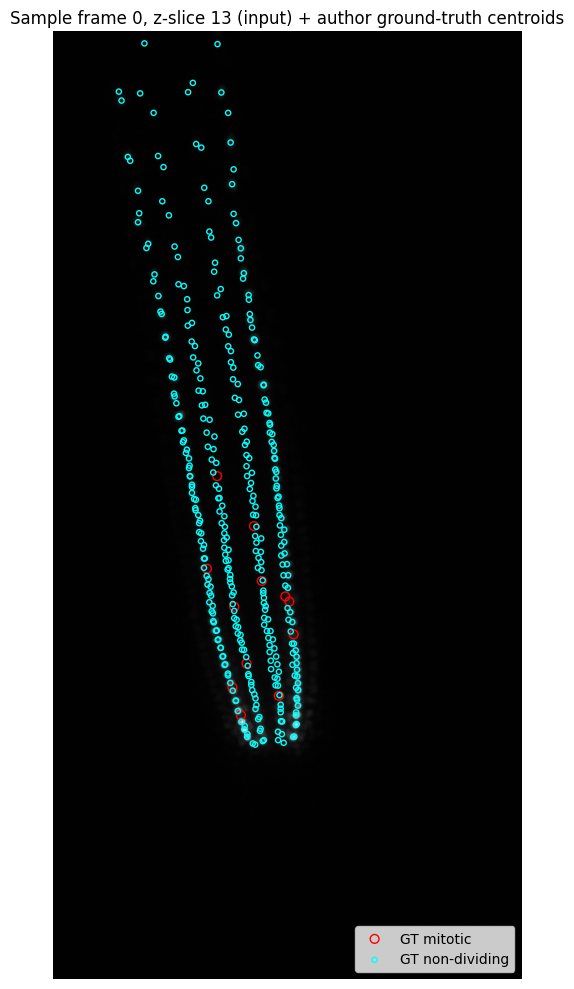

Input volume: (10, 29, 1054, 521) | GT spots in frame 0: 367 (12 mitotic)


In [ ]:
import matplotlib.pyplot as plt

def gt_spot_pixels(xml_path, frame=0):
    root = ET.parse(xml_path).getroot()
    img = root.findall(".//ImageData")[0]
    pw, ph, pd = (float(img.get(k)) for k in ("pixelwidth", "pixelheight", "voxeldepth"))
    sf = root.findall(".//SpotsInFrame")[frame]
    pts, mit = [], []
    for s in sf.findall("Spot"):
        pts.append((float(s.get("POSITION_Z")) / pd, float(s.get("POSITION_Y")) / ph, float(s.get("POSITION_X")) / pw))
        mit.append(s.get("MANUAL_SPOT_COLOR") == "-65536")
    return np.array(pts), np.array(mit)

vol = tifffile.imread(glob.glob("/content/work/*.tif*")[0])
T, Z, Y, X = vol.shape
gt_pts, gt_mit = gt_spot_pixels(gt_xml, frame=0)
zs = int(np.median(gt_pts[:, 0]))
mid = vol[0, zs]
plt.figure(figsize=(6, 10))
plt.title(f"Sample frame 0, z-slice {zs} (input) + author ground-truth centroids")
plt.imshow(mid, cmap="gray")
plt.scatter(gt_pts[gt_mit][:, 2], gt_pts[gt_mit][:, 1], s=40, facecolors="none", edgecolors="red", label="GT mitotic")
plt.scatter(gt_pts[~gt_mit][:, 2], gt_pts[~gt_mit][:, 1], s=14, facecolors="none", edgecolors="cyan", label="GT non-dividing")
plt.legend(loc="lower right"); plt.axis("off"); plt.tight_layout(); plt.show()
print("Input volume:", vol.shape, "| GT spots in frame 0:", len(gt_pts), f"({gt_mit.sum()} mitotic)")


## 5. Detection — pre-trained 2D U-Net ("Automatic Detect")

This ports the GUI's **Cell Detection → Automatic Detect (2D Model)** handler (launch.py:731–772) without its GUI/sleep shell: instantiate the authors' `UNet`, load `unet_2d_best_goh.pth` (`state_dict`), and run the authors' `test_model` slice-by-slice (1024×512 tiles, class 1 = mitotic, class 2 = non-dividing) for every frame, then write spot centroids into a TrackMate XML via the authors' `create_blank_xml` + `xml_from_centroids`. On GPU this is fast; on CPU expect roughly 2–4 s per slice.

**日本語:** GUI の「Automatic Detect (2D Model)」をヘッドレス化したものです。著者の `UNet` にチェックポイントを読み込み、`test_model` でスライスごとに検出し、`xml_from_centroids` で TrackMate XML に書き出します。


In [ ]:
import numpy as np, torch
from torch import load
from cell_detection import UNet, test_model
from ga import get_imlist, create_blank_xml, get_settings, xml_from_centroids
from xml.etree.ElementTree import parse as ps
from skimage import io

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Detection device:", dev)
model = UNet()
model.to(dev)
ckpt = load("/content/author_code/unet_2d_best_goh.pth", map_location=dev)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print("Loaded 2D U-Net state_dict with", len(ckpt["state_dict"]), "tensors")

img_path = get_imlist(WORK)[0]
imgs = io.imread(img_path)
whether_transpose = False
if np.shape(imgs)[-2] < np.shape(imgs)[-1]:
    imgs = imgs.transpose(0, 1, 3, 2)
    whether_transpose = True
print("Sample tensor:", imgs.shape, "| transpose:", whether_transpose)

create_blank_xml(WORK, np.shape(imgs))
xml = get_imlist(WORK, ".xml")
domTree = ps(xml[0])
time_intervel = float(get_settings(WORK)[0].getAttribute("timeinterval"))
print("Detection XML:", xml[0], "| timeinterval =", time_intervel, "s")

cell_id = 0
n_frames = np.shape(imgs)[0]
for idx in range(n_frames):
    commons, mitotics = test_model(model, WORK, idx, imgs, dev, whether_transpose)
    cell_id, domTree = xml_from_centroids(idx, commons, mitotics, domTree, cell_id, time_intervel, WORK)
    print(f"frame {idx}: {len(commons)} non-dividing + {len(mitotics)} mitotic")
domTree.write(xml[0])
print("Wrote", xml[0])


Detection device: cuda


Loaded 2D U-Net state_dict with 96 tensors


Sample tensor: (10, 29, 1054, 521) | transpose: False
Detection XML: /content/work/C2-PointCO2_1_hyper(t101-110).xml | timeinterval = 900.0 s


297
4
frame 0: 297 non-dividing + 4 mitotic


308
5
frame 1: 308 non-dividing + 5 mitotic


...

321
2
frame 5: 321 non-dividing + 2 mitotic


332
2
frame 6: 332 non-dividing + 2 mitotic


322
2
frame 7: 322 non-dividing + 2 mitotic


325
3
frame 8: 325 non-dividing + 3 mitotic


327
3
frame 9: 327 non-dividing + 3 mitotic
Wrote /content/work/C2-PointCO2_1_hyper(t101-110).xml


## 6. Cell-file clustering — GA + k-means ("Automatic Clustering")

Ports **Cell Tracking → Automatic Clustering** (launch.py `ClusteringWorker.run`): for each frame the authors' `ga_processing.read_xml` reads the detection-XML spot positions, searches an optimal projection plane with the genetic algorithm (`ga_plane`: 10,000-population, 3 generations, fitness = std of projected radii), clusters the projected cells into **8 cell files** with seeded k-means (`k_means_8_line`, `random_state=2018`), and writes the per-frame annotation workbook `tracking/points_locations_<idx>.xlsx`. Note: the GA's initial population uses unseeded `np.random.uniform`, so the chosen plane (and hence file labels) can vary slightly between runs; k-means itself is seeded.

**日本語:** 「Automatic Clustering」の移植です。各フレームのスポットを GA で最適化した平面へ投影し、k-means（seed 2018）で 8 つの細胞列にクラスタリングしてワークブックに保存します。GA の初期集団はシードなしのため、実行ごとに平面が若干変わる可能性があります。


In [ ]:
from ga import ga_processing
import time

t0 = time.time()
engine = ga_processing(WORK)
for idx in range(n_frames):
    engine.read_xml(idx)
    print(f"frame {idx} clustered in {time.time()-t0:.0f}s cumulative")
import glob
print(sorted(os.path.basename(p) for p in glob.glob(f"{WORK}/tracking/*.xlsx")))


frame 0 clustered in 43s cumulative


frame 1 clustered in 86s cumulative


frame 2 clustered in 132s cumulative


frame 3 clustered in 178s cumulative


frame 4 clustered in 222s cumulative


frame 5 clustered in 268s cumulative


frame 6 clustered in 315s cumulative


frame 7 clustered in 359s cumulative


frame 8 clustered in 405s cumulative


frame 9 clustered in 452s cumulative
['points_locations_0.xlsx', 'points_locations_1.xlsx', 'points_locations_2.xlsx', 'points_locations_3.xlsx', 'points_locations_4.xlsx', 'points_locations_5.xlsx', 'points_locations_6.xlsx', 'points_locations_7.xlsx', 'points_locations_8.xlsx', 'points_locations_9.xlsx']


### Reset Cell ID

Ports the GUI's **Reset Cell ID** (`sort_id` → `reset_ids` per frame), which rewrites the detection XML with globally consistent, line-ranked spot IDs — the ordering the tracking stage consumes.

**日本語:** 「Reset Cell ID」の移植です。フレーム間で一貫した ID に並べ替えて XML を書き直します。


In [ ]:
from ga import reset_ids, judge_blank_spots

xml = get_imlist(WORK, ".xml")
domTree = ps(xml[0])
dT = judge_blank_spots(domTree)
start_cell_id = 0
for idx in range(n_frames):
    dT, start_cell_id = reset_ids(WORK, idx, dT, start_cell_id, time_intervel)
dT.write(xml[0])
print("Reset IDs; final start_cell_id:", start_cell_id)


Reset IDs; final start_cell_id: 3215


## 7. Lineage tracking ("Track Cells" + "Save XML")

Ports the GUI's **Track Cells** handler (launch.py `track()`): `get_mitotic_color` transfers mitotic flags into the XML, `track_cells` loads all frames' workbooks, and `link_spots` links each cell to its successor(s) in the next frame within the same cell file (writing division links `next_spot_1/2`). Then the **Save XML** handler builds the final TrackMate tracks (`rank_line_then_y`, `judge_blank_track`, `tracked_cells_to_xml`) into `tracked_sample.xml`, loadable in Fiji/TrackMate.

**日本語:** 「Track Cells」と「Save XML」の移植です。同じ細胞列内で次フレームの後継細胞（分裂なら 2 つ）へのリンクを張り、TrackMate 互換のトラック付き XML を出力します。


In [ ]:
from ga import (get_mitotic_color, track_cells, nethermost_8_cells_y,
                reset_excels, link_spots, read_excels_tracked_cell,
                rank_line_then_y, judge_blank_track, tracked_cells_to_xml)

get_mitotic_color(WORK)
all_spots = track_cells(n_frames, WORK)
nethermost, zs, xs = nethermost_8_cells_y(np.array(all_spots[0]))
for i in range(n_frames - 1):
    reset_excels(i, WORK)
    link_spots(np.array(all_spots[i]), np.array(all_spots[i + 1]), i, WORK)
print("Linked spots for", n_frames - 1, "frame transitions")

xml = get_imlist(WORK, ".xml")
domTree = ps(xml[0])
all_cells = [read_excels_tracked_cell(i, WORK) for i in range(n_frames)]
all_cells[0] = rank_line_then_y(all_cells[0])
domTree = judge_blank_track(domTree)
tracked_cells, track_id = [], 0
for i in range(n_frames - 1):
    tracked_cells, track_id, domTree = tracked_cells_to_xml(
        i, all_cells, tracked_cells, n_frames, domTree, track_id, time_intervel)
TRACKED_XML = os.path.join(WORK, "tracked_sample.xml")
domTree.write(TRACKED_XML)
print("Wrote", TRACKED_XML)
root = ET.parse(TRACKED_XML).getroot()
print("Tracks:", len(root.findall(".//Track")))


/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

...

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

/content/author_code/ga.py:961: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_0.next_spot_1[data_0.ID == globals()[f"cells_0_{i}"][j][0]] = globals()[f"cells_1_{i}"][start][0]
/content/author_code/ga.py:961: FutureWarning: ChainedAssign

Linked spots for 9 frame transitions


Wrote /content/work/tracked_sample.xml
Tracks: 514


## 8. Validation against the authors' ground truth

Compare our detections with the ground-truth XML shipped with the samples (frame-by-frame spot counts, and per-spot nearest-neighbour distance in µm using the calibration in the XML). The paper reports slice-wise precision/recall of 86.0/99.0% (non-dividing) and 71.5/95.9% (dividing) on their evaluation data — this sample-level check is a **plausibility check against the authors' own test data**, not a reproduction of those metrics.

**日本語:** 付属の正解 XML とフレームごとの検出数、およびスポットごとの最近傍距離（µm）を比較します。論文の精度指標（precision/recall）の再現ではなく、著者提供テストデータに対する妥当性確認です。


In [ ]:
import pandas as pd
from scipy.spatial import cKDTree

def spots_um(xml_path, frame):
    root = ET.parse(xml_path).getroot()
    img = root.findall(".//ImageData")[0]
    pw, ph, pd = (float(img.get(k)) for k in ("pixelwidth", "pixelheight", "voxeldepth"))
    sf = root.findall(".//SpotsInFrame")[frame]
    pts = np.array([[float(s.get("POSITION_X")), float(s.get("POSITION_Y")), float(s.get("POSITION_Z"))] for s in sf.findall("Spot")])
    mit = np.array([s.get("MANUAL_SPOT_COLOR") == "-65536" for s in sf.findall("Spot")])
    return pts, mit

rows = []
det_root = ET.parse(get_imlist(WORK, ".xml")[0]).getroot()
det_frames = det_root.findall(".//SpotsInFrame")
for f in range(min(n_frames, len(det_frames))):
    dpts, dmit = spots_um(get_imlist(WORK, ".xml")[0], f)
    gpts, gmit = spots_um(gt_xml, f)
    if len(gpts) and len(dpts):
        d_tree = cKDTree(dpts)
        dist, idx = d_tree.query(gpts)
        rows.append({"frame": f, "detected": len(dpts), "ground_truth": len(gpts),
                     "detected_mitotic": int(dmit.sum()), "gt_mitotic": int(gmit.sum()),
                     "mean_NN_um": float(np.mean(dist)), "median_NN_um": float(np.median(dist)),
                     "pct_NN_lt_3um": float(np.mean(dist < 3.0) * 100)})
val = pd.DataFrame(rows)
print(val.to_string(index=False))
val.to_csv("/content/validation_vs_ground_truth.csv", index=False)
print("Saved /content/validation_vs_ground_truth.csv")


 frame  detected  ground_truth  detected_mitotic  gt_mitotic  mean_NN_um  median_NN_um  pct_NN_lt_3um
     0       301           367                 4          12    4.784556      3.495995      45.776567
     1       313           370                 5           9    4.043864      2.883890      52.162162
     2       323           375                 6          10    4.111419      2.375290      56.266667
     3       316           372                 5           9    4.228757      3.059956      49.193548
     4       323           373                 4           8    3.801093      2.341587      54.155496
     5       323           377                 2           4    4.248350      2.658250      52.519894
     6       334           375                 2           4    3.874982      2.237037      56.800000
     7       324           374                 2           5    4.163793      2.879705      51.336898
     8       328           373                 3           5    4.164283      2.50

### Overlay: input slice, ground truth, and model detections

Display the model's detected centroids (dashed magenta circles) for frame 0 next to the ground-truth overlay on the same mid-slice, so the annotation-vs-prediction comparison is directly visible.

**日本語:** フレーム 0 の中央切片に、モデル検出（マゼンタ破線）と正解（赤/シアン）を重ねて比較表示します。


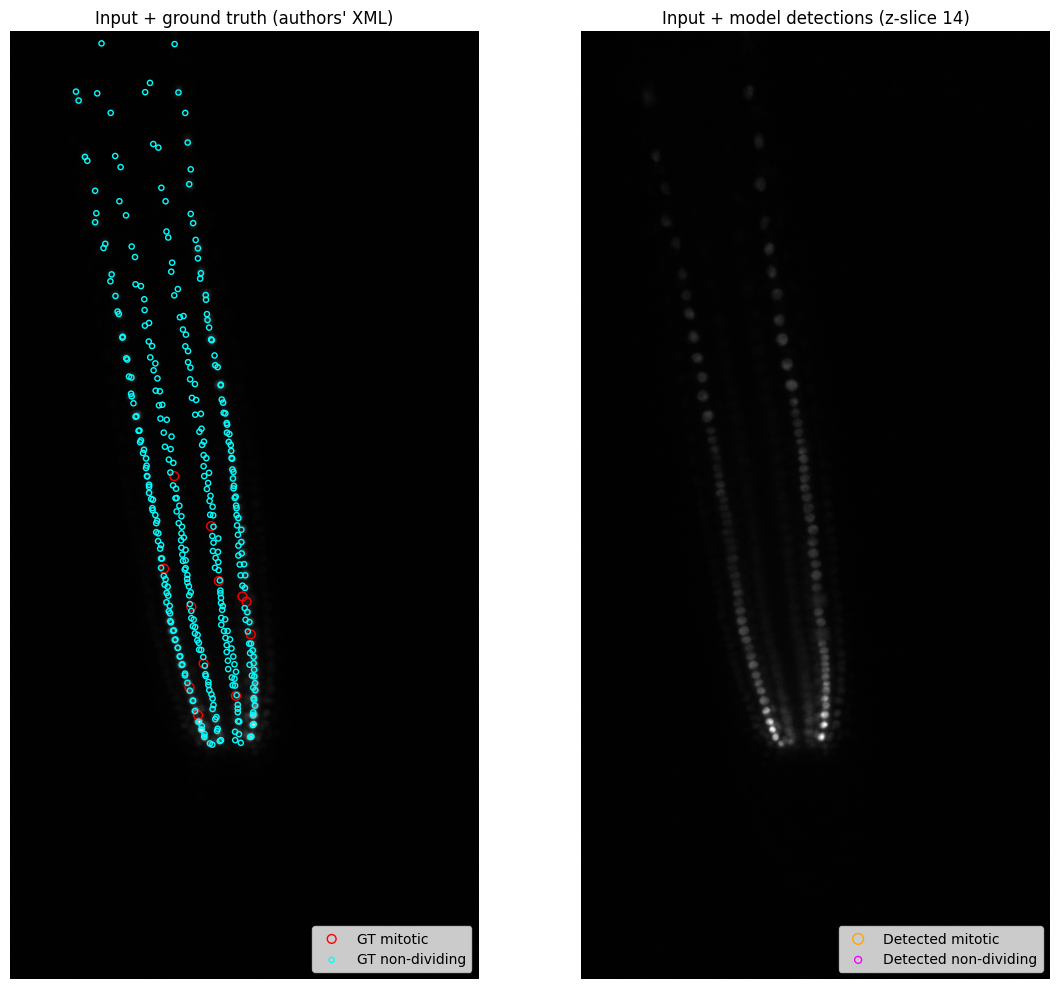

In [ ]:
dpts0, dmit0 = spots_um(get_imlist(WORK, ".xml")[0], 0)
cal_ = ET.parse(get_imlist(WORK, '.xml')[0]).findall('.//ImageData')[0]
pw = float(cal_.get('pixelwidth')); ph = float(cal_.get('pixelheight')); pd_ = float(cal_.get('voxeldepth'))
dpx = dpts0[:, [2, 1, 0]] / np.array([pd_, ph, pw])  # -> columns (z_px, y_px, x_px)
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].set_title("Input + ground truth (authors' XML)")
axes[0].imshow(mid, cmap="gray")
axes[0].scatter(gt_pts[gt_mit][:, 2], gt_pts[gt_mit][:, 1], s=40, facecolors="none", edgecolors="red", label="GT mitotic")
axes[0].scatter(gt_pts[~gt_mit][:, 2], gt_pts[~gt_mit][:, 1], s=14, facecolors="none", edgecolors="cyan", label="GT non-dividing")
axes[0].legend(loc="lower right"); axes[0].axis("off")
zs_d = int(np.median(dpx[:, 0]))  # z is column 0
mid_d = vol[0, zs_d]
axes[1].set_title(f"Input + model detections (z-slice {zs_d})")
axes[1].imshow(mid_d, cmap="gray")
dm = dpx[:, 0] == zs_d
axes[1].scatter(dpx[dm & dmit0][:, 2], dpx[dm & dmit0][:, 1], s=60, facecolors="none", edgecolors="orange", label="Detected mitotic")
axes[1].scatter(dpx[dm & ~dmit0][:, 2], dpx[dm & ~dmit0][:, 1], s=25, facecolors="none", edgecolors="magenta", label="Detected non-dividing")
axes[1].legend(loc="lower right"); axes[1].axis("off")
plt.tight_layout(); plt.show()


## 9. Interpretation and limitations

**What was executed:** the authors' pre-trained 2D U-Net detected nuclei in the 10 provided sample frames, the GA + k-means stage clustered them into 8 cell files, and the lineage tracker exported a TrackMate-compatible XML; detections were compared with the authors' ground truth in the validation table above (frames, counts, nearest-neighbour distances in µm).

**Differences from the paper / limitations (EN):** this is a single-example demonstration of the detection + tracking pipeline, not a reproduction of the paper's dataset-level accuracies, division-dynamics quantification, elongation analysis, or sonification. The GA plane search is only partially seeded, GUI-based manual correction is omitted, and the full 4D dataset remains private ("shared on reasonable request", per the paper's Data Availability).

**日本語:** 実行したのは、提供サンプル 10 フレームに対する検出・クラスタリング・追跡パイプラインの最小デモです。論文のデータセット全体の精度評価・分裂動態解析・ソニフィケーションは対象外です。GA の平面探索は一部シードなしで、GUI による手動修正も省略しています。完全な 4D データは非公開です。

**Provenance:** author code `JerrySongCST/Arabidopsis_root_cortex_cell_tracking` @ `9be8f8110a069186b4eb8510b95b2fb2490e390a` (blob-verified); checkpoints and sample frames from the authors' public Google Drive folders (SHA-256/size printed at download); method paper DOI 10.1093/pcp/pcad105; tracking method arXiv:2504.12676.
